In [1]:
import pandas as pd 
import seaborn as sns 
from matplotlib import pyplot as plt 
import numpy as np
import scipy.stats
import pingouin as pg


Был проведен A/B тест, в рамках которого для новых пользователей из нескольких стран была изменена стоимость премиум-подписки* при покупке через две новые платежные системы. При этом стоимость пробного периода оставалась прежней.

Проверьте:

Был ли эксперимент успешен в целом.
*Деньги за подписку списываются ежемесячно до тех пор, пока пользователь её не отменит.

In [2]:
transactions_control_1 = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-dani-danilov/final_project_danilove/Проект_3_transactions_control_1.csv',sep=';')
transactions_control_2 = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-dani-danilov/final_project_danilove/Проект_3_transactions_control_2.csv',sep=';')
transactions_test = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-dani-danilov/final_project_danilove/Проект_3_transactions_test.csv',sep=';')
users_control_2 = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-dani-danilov/final_project_danilove/Проект_3_users_control_2.csv',sep=';')
users_control_1 = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-dani-danilov/final_project_danilove/Проект_3_users_control_1.csv',sep=';')
users_test = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-dani-danilov/final_project_danilove/Проект_3_users_test.csv',sep=';')

/opt/conda/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# Посмотрим на данные по users_test

In [3]:
users_test.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892309896,27,685,NaN,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12,16,17",1,24,30,89,NaN,NaN,0
1,892044516,27,0,NaN,Germany,NaN,1,24,30,0,NaN,NaN,0
2,892185708,45,44,NaN,Israel,"1,3,4,6,7,8,10,11,12,13,14,15,16,17,18,19,20,2...",1,42,48,68,NaN,NaN,0
3,892130292,32,0,NaN,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12",1,29,35,0,NaN,NaN,0
4,891406035,27,1000,NaN,France,NaN,1,24,30,1,1.0,NaN,0


In [4]:
users_test.shape

(4308, 13)

In [5]:
users_test.uid.nunique() 


4308

Количество строк соответствует количеству уникальных индификаторов, а значит дубликатов нет 

In [6]:
users_test.describe()

,uid,age,attraction_coeff,coins,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
count,4.308000e+03,4308.000000,4308.000000,49.000000,4308.000000,4308.000000,4308.000000,4308.000000,408.0,157.0,4308.000000
mean,8.917437e+08,31.889276,316.411328,229.836735,0.953110,26.701486,38.248839,50.391133,1.0,1.0,534.080316
std,4.547670e+05,10.245287,323.373725,1205.819471,0.211427,9.390851,15.344562,318.676437,0.0,0.0,4371.682632
min,8.910511e+08,16.000000,0.000000,1.000000,0.000000,13.000000,19.000000,0.000000,1.0,1.0,0.000000
25%,8.913621e+08,25.000000,0.000000,4.000000,1.000000,19.000000,28.000000,1.000000,1.0,1.0,0.000000
50%,8.917290e+08,30.000000,250.000000,9.000000,1.000000,24.000000,35.000000,6.000000,1.0,1.0,0.000000
75%,8.920952e+08,38.000000,520.250000,72.000000,1.000000,32.000000,44.000000,22.000000,1.0,1.0,0.000000
max,9.051586e+08,99.000000,1000.000000,8466.000000,1.000000,96.000000,102.000000,12831.000000,1.0,1.0,129870.000000


In [7]:
users_test.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins               4259
country                0
visit_days          1330
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3900
is_premium          4151
total_revenue          0
dtype: int64

1. Видим пустые значение в "Coins" (а именно 98% строк имеют Null). Из этого факта я предпологаю, что null - не отсутствие значения, а отсутствие самих "койнов", а значит пустые значения мы заменим на 0 

2. Пустые visit_days означают, что пользватель не возрващался в продукт после регистрации 

3. Пустые значения в was_premium и is_premium также считаю за 0, так как исходя из распределения этих величин мы видим что минимальные значения = 1, а значит null = 0 

# Users_control_1

In [8]:
users_control_1.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892319115,25,435,NaN,United States of America,"1,2,3,4,5,6",0,22,32,982,NaN,NaN,0
1,891248523,29,500,NaN,United States of America,"1,2",1,26,32,12,NaN,NaN,0
2,891670932,33,800,NaN,France,"1,2,3,5,6,8,9,11,13,16",1,30,36,5,NaN,NaN,0
3,891060786,26,0,NaN,Argentina,"1,2,3,4,5",1,23,29,0,NaN,NaN,0
4,892006554,35,294,NaN,United States of America,"1,2,3,5,6,7,8,9,10,12,15,16,17,19",1,30,40,17,NaN,NaN,0


In [9]:
users_control_1.shape

(4340, 13)

In [10]:
users_control_1.uid.nunique()  # также дубликатов не наблюдается 

4340

In [11]:
users_control_1.describe()

,uid,age,attraction_coeff,coins,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
count,4.340000e+03,4340.000000,4340.000000,60.0000,4340.000000,4340.000000,4340.000000,4340.000000,436.0,192.0,4340.000000
mean,8.917578e+08,32.095392,312.048848,1745.9000,0.958065,26.793779,38.553226,44.467512,1.0,1.0,594.761982
std,1.125683e+06,10.257466,320.972130,12902.3577,0.200465,9.405103,15.226951,204.800272,0.0,0.0,7987.922925
min,8.910510e+08,16.000000,0.000000,1.0000,0.000000,13.000000,19.000000,0.000000,1.0,1.0,0.000000
25%,8.913626e+08,24.000000,0.000000,8.0000,1.000000,19.000000,28.000000,1.000000,1.0,1.0,0.000000
50%,8.917272e+08,30.000000,238.500000,11.5000,1.000000,25.000000,35.000000,6.000000,1.0,1.0,0.000000
75%,8.920898e+08,38.000000,518.000000,28.0000,1.000000,32.000000,45.000000,21.000000,1.0,1.0,0.000000
max,9.609370e+08,99.000000,1000.000000,99958.0000,1.000000,96.000000,102.000000,4953.000000,1.0,1.0,486330.000000


In [12]:
users_control_1.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins               4280
country                0
visit_days          1324
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3904
is_premium          4148
total_revenue          0
dtype: int64

# Users_control_2

In [13]:
users_control_2.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892035504,37,137,NaN,Israel,"1,2,3,4,5,6,7,8,9,11,13",1,30,40,51,NaN,NaN,0
1,891782112,57,0,NaN,Italy,1,1,54,60,0,NaN,NaN,0
2,891110337,30,769,NaN,France,"1,2,3,4,5",1,27,33,13,NaN,NaN,0
3,891796320,48,750,NaN,France,"1,4,6,8,10,11,12,14,15,16,18",1,45,51,12,NaN,NaN,0
4,891880212,54,638,NaN,United States of America,1,1,35,53,94,NaN,NaN,0


In [14]:
users_control_2.shape


(4264, 13)

In [15]:
users_control_2.uid.nunique() # и тут всё отлично 

4264

In [16]:
users_control_2.describe()

,uid,age,attraction_coeff,coins,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
count,4.264000e+03,4264.000000,4264.000000,61.000000,4264.000000,4264.000000,4264.000000,4264.000000,411.0,191.0,4264.000000
mean,8.917694e+08,32.046201,317.957317,18.147541,0.954268,26.954268,38.906895,45.064493,1.0,1.0,450.384146
std,2.520759e+06,10.170721,326.191737,35.439543,0.208927,9.546657,15.955574,318.188992,0.0,0.0,2859.242228
min,8.910509e+08,16.000000,0.000000,1.000000,0.000000,13.000000,19.000000,0.000000,1.0,1.0,0.000000
25%,8.913453e+08,25.000000,0.000000,4.000000,1.000000,19.000000,28.000000,1.000000,1.0,1.0,0.000000
50%,8.917205e+08,30.000000,250.000000,10.000000,1.000000,25.000000,35.000000,6.000000,1.0,1.0,0.000000
75%,8.920735e+08,38.000000,548.500000,20.000000,1.000000,32.000000,45.000000,20.000000,1.0,1.0,0.000000
max,1.053059e+09,99.000000,1000.000000,271.000000,1.000000,94.000000,99.000000,16157.000000,1.0,1.0,81796.000000


In [17]:
users_control_2.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins               4203
country                0
visit_days          1364
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3853
is_premium          4073
total_revenue          0
dtype: int64

# Преобразуем данные users

Логику в в данных (описанную выше) мы наблюдаем и на контрольных группах, поэтому преобразуем пустые значения

In [18]:
values = {'coins':0,'was_premium':0,'is_premium':0}



users_test.fillna(value=values,inplace=True)
users_control_1.fillna(value=values,inplace=True)
users_control_2.fillna(value=values,inplace=True)

In [19]:
users_test.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins                  0
country                0
visit_days          1330
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium            0
is_premium             0
total_revenue          0
dtype: int64

Поработаем с типами данных:


In [20]:
users_control_1.dtypes

uid                   int64
age                   int64
attraction_coeff      int64
coins               float64
country              object
visit_days           object
gender                int64
age_filter_start      int64
age_filter_end        int64
views_count           int64
was_premium         float64
is_premium          float64
total_revenue         int64
dtype: object

In [21]:
users_test.was_premium = users_test.was_premium.astype(bool)
users_control_1.was_premium = users_control_1.was_premium.astype(bool)
users_control_2.was_premium = users_control_2.was_premium.astype(bool)

users_test.is_premium = users_test.is_premium.astype(bool)
users_control_1.is_premium = users_control_1.is_premium.astype(bool)
users_control_2.is_premium = users_control_2.is_premium.astype(bool)


In [22]:
users_control_1.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892319115,25,435,0.0,United States of America,"1,2,3,4,5,6",0,22,32,982,False,False,0
1,891248523,29,500,0.0,United States of America,"1,2",1,26,32,12,False,False,0
2,891670932,33,800,0.0,France,"1,2,3,5,6,8,9,11,13,16",1,30,36,5,False,False,0
3,891060786,26,0,0.0,Argentina,"1,2,3,4,5",1,23,29,0,False,False,0
4,892006554,35,294,0.0,United States of America,"1,2,3,5,6,7,8,9,10,12,15,16,17,19",1,30,40,17,False,False,0


# Посмотрим, не попали ли люди из одной группы в другую

In [23]:
set(users_test.uid).intersection(set(users_control_1.uid))

set()

In [24]:
set(users_test.uid).intersection(set(users_control_2.uid))

set()

In [25]:
set(users_control_2.uid).intersection(set(users_control_1.uid))

set()

Всё отлично

# Смотрим транзакции

In [26]:
transactions_test.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891345942,Italy,2017-05-11 13:00:00,2017-11-13 15:04:00,12909,147,trial_vip_popup,trial_premium
1,892054251,United States of America,2017-10-22 00:33:00,2017-10-30 01:37:00,13923,147,trial_vip_popup,trial_premium
2,892236423,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783,67,menu,other_type
3,892236423,United States of America,2017-10-18 01:09:00,2017-10-27 22:38:00,3783,67,menu,other_type
4,892168170,United States of America,2017-10-19 17:10:00,2017-10-27 19:10:00,9087,147,trial_vip_popup,trial_premium


In [27]:
transactions_test.dtypes

uid              int64
country         object
joined_at       object
paid_at         object
revenue          int64
payment_id       int64
from_page       object
product_type    object
dtype: object

Преобразуем даты в из object в datetime

In [28]:
transactions_test.joined_at = pd.to_datetime(transactions_test.joined_at,format='%Y-%m-%d')
transactions_test.paid_at = pd.to_datetime(transactions_test.paid_at,format='%Y-%m-%d')


In [29]:
transactions_test.dtypes

uid                      int64
country                 object
joined_at       datetime64[ns]
paid_at         datetime64[ns]
revenue                  int64
payment_id               int64
from_page               object
product_type            object
dtype: object

In [30]:
transactions_control_1.joined_at = pd.to_datetime(transactions_control_1.joined_at,format='%Y-%m-%d')
transactions_control_1.paid_at = pd.to_datetime(transactions_control_1.paid_at,format='%Y-%m-%d')


In [31]:
transactions_control_1.dtypes

uid                    float64
country                 object
joined_at       datetime64[ns]
paid_at         datetime64[ns]
revenue                float64
payment_id             float64
from_page               object
product_type            object
dtype: object

In [32]:
transactions_control_2.joined_at = pd.to_datetime(transactions_control_2.joined_at,format='%Y-%m-%d')
transactions_control_2.paid_at = pd.to_datetime(transactions_control_2.paid_at,format='%Y-%m-%d')


In [33]:
transactions_control_2.dtypes

uid                      int64
country                 object
joined_at       datetime64[ns]
paid_at         datetime64[ns]
revenue                  int64
payment_id               int64
from_page               object
product_type            object
dtype: object

# Дубликаты в транзакциях

In [34]:
transactions_test.shape

(273, 8)

In [35]:
transactions_test.payment_id.nunique()

6

In [36]:
transactions_test.duplicated().sum()

7

In [37]:
transactions_test.query('payment_id == 147')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891345942,Italy,2017-05-11 13:00:00,2017-11-13 15:04:00,12909,147,trial_vip_popup,trial_premium
1,892054251,United States of America,2017-10-22 00:33:00,2017-10-30 01:37:00,13923,147,trial_vip_popup,trial_premium
4,892168170,United States of America,2017-10-19 17:10:00,2017-10-27 19:10:00,9087,147,trial_vip_popup,trial_premium
5,892426491,United States of America,2017-10-14 10:13:00,2017-10-15 22:39:00,12597,147,autoreply_message,premium_no_trial
6,891558921,United States of America,2017-01-11 03:07:00,2017-10-11 09:05:00,9100,147,left_sidebar_menu,premium_no_trial
...,...,...,...,...,...,...,...,...
265,891572565,United Arab Emirates,2017-10-31 20:40:00,2017-05-11 13:32:00,9217,147,promo_09,premium_no_trial
266,891478452,United Arab Emirates,2017-02-11 23:29:00,2017-12-11 00:11:00,8697,147,autoreply_message,premium_no_trial
267,891414915,Argentina,2017-04-11 09:06:00,2017-04-11 09:56:00,6292,147,autoreply_message,premium_no_trial
268,891419625,Israel,2017-04-11 05:58:00,2017-11-11 08:33:00,14352,147,trial_vip_popup,trial_premium


Как видим на примере в датасете есть 2 проблемы:
1. payment_id = неуникален, один id платежа соотвествует разным платежам разных пользователей!
2. Есть дубликаты 


In [38]:
transactions_test[transactions_test.duplicated()==True]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
55,892236423,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783,67,menu,other_type
96,892050108,Israel,2017-10-22 03:02:00,2017-10-23 02:53:00,1261,19,empty_likes,coins
127,892236423,United States of America,2017-10-18 01:09:00,2017-10-27 22:38:00,3783,67,menu,other_type
158,891508155,Latvia,2017-02-11 09:46:00,2017-03-11 22:06:00,936,19,empty_likes,coins
188,892236423,United States of America,2017-10-18 01:09:00,2017-10-22 22:08:00,1261,19,empty_likes,coins
205,892202526,United States of America,2017-10-18 20:34:00,2017-10-20 19:54:00,897,19,menu,coins
243,892339626,United States of America,2017-10-15 23:21:00,2017-10-20 18:14:00,754,19,empty_likes,coins


Удаляем дубликаты:

In [39]:
transactions_test.drop_duplicates(inplace=True)

Рассмотрим дубликаты подробнее но по колонкам:

In [40]:
transactions_test[transactions_test.duplicated(subset=['uid','paid_at','revenue','product_type'],keep=False)]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
152,891725043,United Arab Emirates,2017-10-29 00:49:00,2017-10-29 07:48:00,9217,147,none,premium_no_trial
220,891725043,United Arab Emirates,2017-10-29 00:49:00,2017-10-29 07:48:00,9217,0,none,premium_no_trial


Данную ситуацию считаю спорной
Есть несколько гипотез:

1. Дублирование записей - данные о транзакции продублировались и эту запись нужно устранить
2. Техническая проблема - оплата прошла 2 раза (но у нас нет данных о том, был ли возврат этой оплаты) 
3. Оплата подписки на 2 месяца - но и тут у нас нет данных о том, есть ли такая возможность на платформе в принципе 

Поэтому транзакции с одинаковой датой я буду удалять (ссылаясь на неполадку), а данные с разным временем (пусть и в 2-3 минуты) считать как дополнительную покупку подписки на месяц, 7 дней вперед и тд

In [41]:
transactions_test.drop_duplicates(subset=['uid','paid_at','revenue','product_type'],inplace=True)

# Рассмотрим транзакции в 1 контрольной группе

In [42]:
transactions_control_1

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891319275.0,France,2017-05-11 19:57:00,2017-12-11 21:57:00,12727.0,147.0,trial_vip_popup,trial_premium
1,892421826.0,Israel,2017-10-14 12:46:00,2017-10-23 12:54:00,14586.0,147.0,trial_vip_popup,trial_premium
2,891822480.0,Italy,2017-10-26 22:27:00,2017-12-11 20:59:00,1911.0,19.0,none,coins
3,891367521.0,Italy,2017-05-11 02:37:00,2017-06-11 19:15:00,1456.0,127.0,sympathy,other_type
4,892207959.0,France,2017-10-18 18:30:00,2017-12-11 12:03:00,1261.0,19.0,empty_likes,coins
...,...,...,...,...,...,...,...,...
1002,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
1003,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
1004,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
1005,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN


In [43]:
transactions_control_1.describe()

,uid,revenue,payment_id
count,3.770000e+02,377.000000,377.000000
mean,8.923612e+08,6929.206897,91.145889
std,6.162900e+06,8027.889630,58.599773
min,8.910923e+08,26.000000,0.000000
25%,8.913833e+08,2730.000000,19.000000
50%,8.918225e+08,6266.000000,127.000000
75%,8.921850e+08,6448.000000,147.000000
max,9.609370e+08,63037.000000,147.000000


In [44]:
transactions_control_1.isna().sum()

uid             630
country         630
joined_at       630
paid_at         630
revenue         630
payment_id      630
from_page       630
product_type    630
dtype: int64

Уберём пустые значения:

In [45]:
transactions_control_1 = transactions_control_1.dropna(subset=['uid', 'paid_at', 'revenue'])

In [46]:
transactions_control_1.isna().sum()

uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
dtype: int64

In [47]:
transactions_control_1.duplicated(subset=['uid','paid_at','revenue','product_type']).sum()

30

In [48]:
transactions_control_1 = transactions_control_1.copy() 
transactions_control_1.drop_duplicates(subset=['uid','paid_at','revenue','product_type'],inplace=True)


Поясню ещё раз почему именно такой фильтр по дубликатам 

Мы можем представить себе ситуации когда клиент оформляет одновременно 2 вида продукта (так совпало что платежи также одинаковые): к примеру оплата подписки и пополнение койнов 

Но чтоб один и тот же продукт был оформлен 2 одновременными платежами мы представить не можем (поэтому я ссылаюсь на дубликат и техническую проблему в записи данных) 

# Транзакции во 2 группе

In [49]:
transactions_control_2.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891266616,Argentina,2017-06-11 15:25:00,2017-10-11 17:35:00,6305,19,autorefill,coins
1,892186737,Chile,2017-10-19 06:03:00,2017-04-11 08:53:00,4732,147,promo_09,premium_no_trial
2,891959004,United States of America,2017-10-24 00:12:00,2017-10-31 02:12:00,10153,147,trial_vip_popup,trial_premium
3,892115478,Spain,2017-10-20 20:39:00,2017-10-26 06:26:00,2366,67,empty_likes,other_type
4,891592941,Switzerland,2017-10-31 12:40:00,2017-03-11 16:25:00,6292,147,promo_09,premium_no_trial


In [50]:
transactions_control_2.describe()

,uid,revenue,payment_id
count,3.280000e+02,328.000000,328.000000
mean,8.918121e+08,5854.993902,95.527439
std,3.802149e+05,6582.242539,57.247832
min,8.910681e+08,481.000000,0.000000
25%,8.915738e+08,2323.750000,19.000000
50%,8.918626e+08,4706.000000,146.000000
75%,8.921281e+08,6314.750000,147.000000
max,8.924388e+08,81796.000000,147.000000


In [51]:
transactions_control_2.isna().sum() # пустые значения отсутствуют 

uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
dtype: int64

In [52]:
transactions_control_2.duplicated(subset=['uid','paid_at','revenue','product_type']).sum() 

14

In [53]:
transactions_control_2.drop_duplicates(subset=['uid','paid_at','revenue','product_type'],inplace=True)

In [54]:
transactions_control_2.duplicated(subset=['uid','paid_at','revenue','product_type']).sum() 

0

# Проверим не перемешались ли транзакции 
Нет ли транзакций одного человека в разных группах

In [55]:
set(transactions_test.uid).intersection(set(transactions_control_1.uid))

set()

In [56]:
set(transactions_test.uid).intersection(set(transactions_control_2.uid))

set()

In [57]:
set(transactions_control_1.uid).intersection(set(transactions_control_2.uid))

set()

# Проверка на соответствие 


Посмотрим все ли люди из транзакций есть в юзерах

In [58]:
transactions_test[~transactions_test.uid.isin(users_test.uid)]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type


In [59]:
transactions_control_1[~transactions_control_1.uid.isin(users_control_1.uid)]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type


In [60]:
transactions_control_2[~transactions_control_2.uid.isin(users_control_2.uid)]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type


Транзакций клиентов не состоящих в датасете юзеров не наблюдается 

# Объединение данных

Для дальнейшей простоты работы объединим данные в единые датасеты 

In [61]:
users_test['group'] = 'test'
users_control_1['group'] = 'control_1'
users_control_2['group'] = 'control_2'

transactions_test['group'] = 'test'
transactions_control_1['group'] = 'control_1'
transactions_control_2['group'] = 'control_2'

In [62]:
users = pd.concat([users_test, users_control_1, users_control_2], ignore_index=True)
transactions = pd.concat([transactions_test, transactions_control_1, transactions_control_2], ignore_index=True)

In [63]:
users.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,group
0,892309896,27,685,0.0,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12,16,17",1,24,30,89,False,False,0,test
1,892044516,27,0,0.0,Germany,NaN,1,24,30,0,False,False,0,test
2,892185708,45,44,0.0,Israel,"1,3,4,6,7,8,10,11,12,13,14,15,16,17,18,19,20,2...",1,42,48,68,False,False,0,test
3,892130292,32,0,0.0,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12",1,29,35,0,False,False,0,test
4,891406035,27,1000,0.0,France,NaN,1,24,30,1,True,False,0,test


Посмотрим на интересный момент:

In [64]:
users.query('is_premium == True').uid.nunique()

540

In [65]:
transactions.query('product_type not in ("coins","other_type")').uid.nunique()

448

Пользователей с активным статусом премиум больше чем пользователей активировавших премиум в транзакциях

Возьмём это на заметку 

# Соответствие выручек в транзакциях и в данных клиентов

In [66]:
total_revenue_transactions = transactions.groupby('uid').revenue.sum()
users_total_revenue = users.set_index('uid').total_revenue
result = total_revenue_transactions.reindex(users_total_revenue.index, fill_value=0) == users_total_revenue
#Есть несоответствие между транзакциями и total_revenue в users!!!!!!!!!
result.reset_index(name='Value').query('Value == False')

,uid,Value
406,892236423,False
761,891508155,False
1736,892050108,False
1900,892339626,False
2070,892275462,False
2630,892202526,False
2935,891725043,False
4567,891367521,False
4818,960936960,False
5523,892101909,False


In [67]:
diff_users_transactions= total_revenue_transactions.reindex(users_total_revenue.index, fill_value=0) - users_total_revenue
diff_users_transactions.reset_index(name='diff').query('diff !=0')

,uid,diff
406,892236423,-8827.0
761,891508155,-936.0
1736,892050108,-1261.0
1900,892339626,-754.0
2070,892275462,44083.0
2630,892202526,-897.0
2935,891725043,-9217.0
4567,891367521,-8775.0
4818,960936960,780.0
5523,892101909,-6422.0


 Рассмотрим транзакции одно из пользователей у которого есть несоответствия 

In [68]:
transactions.query('uid == 892236423')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group
2,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783.0,67.0,menu,other_type,test
3,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-27 22:38:00,3783.0,67.0,menu,other_type,test
17,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-22 22:08:00,1261.0,19.0,empty_likes,coins,test
80,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-23 00:14:00,31525.0,19.0,menu,coins,test
96,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-23 00:14:00,12610.0,19.0,menu,coins,test
110,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-22 22:09:00,12610.0,19.0,empty_likes,coins,test
123,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-18 01:15:00,6292.0,147.0,left_sidebar_menu,premium_no_trial,test
136,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-22 22:08:00,3783.0,67.0,empty_likes,other_type,test
163,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-23 00:14:00,3783.0,67.0,menu,other_type,test
208,892236423.0,United States of America,2017-10-18 01:09:00,2017-10-22 22:08:00,6305.0,19.0,empty_likes,coins,test


Мы видим что тут есть совпадения как по времени транзакции (но с разной выручкой), так и по размеру выручки (но с разным временем)
Логику удаления дубликатов я описывал выше, поэтому я считаю датафрейм transactions как источник истины

Это мы также возьмём на заметку

# Логическое соответствие 

Транзакция не может быть проведена раньше чем присоединение пользователя 

In [69]:
transactions[transactions['paid_at'] < transactions['joined_at']]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group
11,891861048.0,Canada,2017-10-26 02:55:00,2017-10-11 19:00:00,3588.0,68.0,none,premium_no_trial,test
20,891806280.0,United States of America,2017-10-27 08:56:00,2017-03-11 10:57:00,8242.0,147.0,trial_vip_popup,trial_premium,test
24,891786216.0,Spain,2017-10-27 18:20:00,2017-03-11 20:20:00,12818.0,147.0,trial_vip_popup,trial_premium,test
25,892057347.0,France,2017-10-21 23:15:00,2017-08-11 01:56:00,1209.0,19.0,none,coins,test
36,891589239.0,Italy,2017-10-31 14:16:00,2017-09-11 15:44:00,6305.0,19.0,empty_likes,coins,test
...,...,...,...,...,...,...,...,...,...
905,891606141.0,United States of America,2017-10-31 04:43:00,2017-03-11 21:13:00,3783.0,67.0,empty_likes,other_type,control_2
912,891691062.0,Belgium,2017-10-29 16:19:00,2017-05-11 18:35:00,16614.0,147.0,popular_users_block,trial_premium,control_2
913,892075512.0,United States of America,2017-10-21 16:58:00,2017-08-11 12:18:00,9958.0,147.0,trial_vip_popup,trial_premium,control_2
914,891722802.0,United States of America,2017-10-29 02:08:00,2017-05-11 05:49:00,12727.0,147.0,trial_vip_popup,trial_premium,control_2


Логически этой ситуации не может быть, эти транзакции считаю ошибочными 

Было бы хорошо по этому поводу необходимо к источнику данных (инженеры) и решить этот вопрос

In [70]:
transactions_no_logic = transactions[transactions['paid_at'] < transactions['joined_at']]
transactions_no_logic.uid.nunique() # Количество пользователей с "нелогичными транзакциями"

113

Выше мы выявили несоответствие количества покупок премиумама и людей обладающих этим статусом 
Мне необходимо просмотреть транзакции о покупках премиум статуса, и найти пользователей нарушающих логику

In [71]:
no_logic_premium = transactions_no_logic.query('product_type not in ("coins","other_type")')

In [72]:
transactions[transactions['uid'].isin(no_logic_premium.uid)].query('paid_at > joined_at').head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group
23,891861048.0,Canada,2017-10-26 02:55:00,2017-10-28 16:30:00,3549.0,19.0,none,coins,test
52,892065108.0,France,2017-10-21 20:40:00,2017-12-11 02:10:00,3913.0,19.0,menu,coins,test
72,891654090.0,United States of America,2017-10-30 05:59:00,2017-10-31 05:50:00,19500.0,146.0,menu,coins,test
87,891654090.0,United States of America,2017-10-30 05:59:00,2017-10-31 05:55:00,2327.0,67.0,fans,other_type,test
111,892261437.0,Italy,2017-10-17 14:22:00,2017-10-26 16:06:00,1937.0,68.0,none,premium_no_trial,test


Что я сейчас сделал? 

У нас есть транзакции которые не соответсвтуют логике (покупка раньше регестрации), но у части пользователей есть и нормальные транзакции (покупка после регистрации) 

1. Мы уберём все транзакции, что не соответствуют логике
2. Пересчитаем total_revenue по логически верным транзакциям
3. Изменим статус премиума (если транзакций о покупке премиуама у человека более не было) 

In [73]:
transactions = transactions[transactions['paid_at'] > transactions['joined_at']]

In [74]:
new_total_revenue = transactions.groupby('uid').revenue.sum() #Длеаем новую сумму выручки для пользователей 
users.set_index('uid',inplace=True) # Ставим uid в индекс для проведения изменений 
users['total_revenue'] = new_total_revenue.reindex(users.index,fill_value=0) # Меняем значения (при отсутствии 0)
users.reset_index(inplace=True) # Возвращаем uid из индекса 

In [75]:
print(f"Сумма в users: {users['total_revenue'].sum():.2f}")
print(f"Сумма в transactions: {transactions['revenue'].sum():.2f}")

Сумма в users: 5543057.00
Сумма в transactions: 5543057.00


Теперь выручка по пользователям соответсвтует данным по транзакциям

Теперь помотрим на тех юзеров, кто больше не должен быть в статусе is_premium

In [76]:
uids_with_premium = transactions.query('product_type not in ("other_type","coins")').uid.unique() # uid тех кто покупал премиум 
problematic_users = users[~users['uid'].isin(uids_with_premium) & users['is_premium']==True] 
# Пользователи у которых по транзакциям не должно быть премиума


In [77]:
problematic_users.shape[0] / users.query('is_premium == True').shape[0] 

0.37037037037037035

In [78]:
users.query('is_premium == True')

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,group
20,891152790,29,769,0.0,Spain,"2,5,6",1,16,32,13,True,True,12597.0,test
44,891589239,21,303,37.0,Italy,"1,2,3,4,5,6,7,8,9",1,18,24,181,True,True,18902.0,test
100,891343671,26,0,24.0,France,"1,2,3,4,5,6,7,8,9",1,23,35,37,True,True,21580.0,test
105,892430988,28,181,0.0,United States of America,"1,2",1,25,31,22,True,True,12727.0,test
134,891919368,29,250,0.0,France,NaN,1,26,32,4,True,True,16536.0,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12811,892186737,30,250,0.0,Chile,"1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16",1,27,33,8,True,True,0.0,control_2
12834,891097317,29,1000,0.0,Canada,NaN,1,26,32,1,True,True,0.0,control_2
12838,891452592,49,127,0.0,France,"1,2,3,4,5,6,7,8,9,10,11,12",1,39,48,837,True,True,15626.0,control_2
12839,891055815,24,0,0.0,Portugal,1,1,21,27,0,True,True,0.0,control_2


37% пользователей из тех что имеют статус премиума не должны им обладать

На самом деле это огромная доля, но из-за того что сейчас мы вооружены ограниченным набором данных и не можем исследовать эту проблему подробнее, то вынуждены убрать у этих пользователей статус обладания премиумом

In [79]:
users.set_index('uid',inplace=True) #Ставим uid в индекс для операции

In [80]:

users.loc[problematic_users.uid.unique(),'is_premium'] = False 

In [81]:
users.reset_index(inplace=True)

Проверим, получилось ли:

In [82]:
uids_with_premium = transactions.query('product_type not in ("other_type","coins")').uid.unique() # uid тех кто покупал премиум 
problematic_users = users[~users['uid'].isin(uids_with_premium) & users['is_premium']==True] 
# Пользователи у которых по транзакциям не должно быть премиума

problematic_users.shape[0] / users.query('is_premium == True').shape[0] 

0.0

Всё отлично

# Сравнение групп 

С самими данными вроде поработали, преступим к сравнению показателей 

In [83]:
users['group_combined'] = users['group'].replace({
    'control_1': 'control',
    'control_2': 'control',
    'test': 'test'
})

In [84]:
transactions['group_combined'] = transactions['group'].replace({
    'control_1': 'control',
    'control_2': 'control',
    'test': 'test'
})

Мы будем проверять то, что контрольные группы не различаются друг от друга и объеденять их для увеличения мощности тестов

In [85]:
users.group.value_counts() # Количество пользователей в группах примерно одинаковое 

control_1    4340
test         4308
control_2    4264
Name: group, dtype: int64

Проверим, нет ли различий конверсий в контрольных группах

На данном этапе появляется вопрос по колонкам was_premium и is_premium 

Если у нас данные по A/B тесту и was_premium считается на момент теста, а is_premium в свою очередь на момент просмотра, то для расчёта конверсии нужно смотреть was_premium (сколько людей оформили премиум за время тестирования) 

А если у нас was_premium глобально (за всё время клиента в сервисе), а is_premium за время теста (оформление во время тестирования), то для расчёта конверсии нужно брать is_premium 

Я буду придерживаться 2 логики и считать что показатель is_premium = факт покупки во время тестирования 



# Конверсия премиуама в группах

In [86]:
users_control = users.query('group in ("control_1","control_2")')
scipy.stats.chi2_contingency(pd.crosstab(users_control.group,users_control.is_premium)).pvalue 

0.5189379561856992

Конверсии в контрольных группах не различаются

In [87]:
conversion_contingency_table = pd.crosstab(users.group,users.is_premium)
conversion_contingency_table

is_premium,False,True
group,,
control_1,4213,127
control_2,4150,114
test,4209,99


In [88]:
scipy.stats.chi2_contingency(conversion_contingency_table).pvalue 

0.18560001706795337

In [89]:
pd.crosstab(users.group_combined,users.is_premium)

is_premium,False,True
group_combined,,
control,8363,241
test,4209,99


In [90]:
scipy.stats.chi2_contingency(pd.crosstab(users.group_combined,users.is_premium)).pvalue 

0.10421973406561721

Более того, мы не видим статистически значимого разлиичия в конверсии даже в сравнении с тестовой группой 

# Распределение пользователей по городам

Теперь проверим равное ли распределение по городам в группах

In [91]:
contingency_country = users.groupby(['group','country'],as_index=False).uid.count() \
.pivot(index='country',columns='group',values='uid').fillna(0)

contingency_country # таблица сопряжённости для городов 

group,control_1,control_2,test
country,,,
Algeria,2.0,0.0,2.0
Argentina,389.0,397.0,396.0
Armenia,1.0,0.0,0.0
Australia,50.0,51.0,62.0
Austria,0.0,2.0,0.0
...,...,...,...
United Kingdom (Great Britain),146.0,146.0,169.0
United States of America,1471.0,1486.0,1450.0
Uruguay,0.0,1.0,1.0


In [92]:
chi_2, p, dof, expected = scipy.stats.chi2_contingency(contingency_country[['control_1','control_2','test']])

Из курса статистики мы знаем, что ожидаемое количетсво наблюденей в ячейке должно быть не менее 5

Для этого мы воспользовались встроеной функцией и вытащили массив из ожидаемых значений 

Давайте найдём те страны, в ячейках которых ожидаемое значение будет меньше 5 и объеденим их в одну категорию "другое"

In [93]:
expected_df = pd.DataFrame(index=contingency_country.index,columns=contingency_country.columns,data=expected)
expected_df

group,control_1,control_2,test
country,,,
Algeria,1.344486,1.320942,1.334572
Argentina,397.295539,390.338290,394.366171
Armenia,0.336121,0.330235,0.333643
Australia,54.787794,53.828377,54.383829
Austria,0.672243,0.660471,0.667286
...,...,...,...
United Kingdom (Great Britain),154.951983,152.238538,153.809480
United States of America,1481.287175,1455.347584,1470.365242
Uruguay,0.672243,0.660471,0.667286


In [94]:
country_for_other =  (expected_df > 5).sum(axis=1).reset_index(name='value').query('value < 3').country
#Отбираем страны которые будут объеденены в одну группу
country_for_contingency = (expected_df > 5).sum(axis=1).reset_index(name='value').query('value == 3').country

In [95]:
other = contingency_country.loc[country_for_other].sum()

In [96]:
contingency_country_clear = contingency_country.loc[country_for_contingency]
contingency_country_clear.loc['Other'] = other
contingency_country_clear

group,control_1,control_2,test
country,,,
Argentina,389.0,397.0,396.0
Australia,50.0,51.0,62.0
Belgium,108.0,90.0,92.0
Canada,134.0,134.0,137.0
Chile,287.0,286.0,272.0
France,370.0,376.0,359.0
Germany,188.0,202.0,209.0
Israel,109.0,78.0,106.0
Italy,338.0,293.0,323.0


Сравним контрольные группы

In [97]:
scipy.stats.chi2_contingency(contingency_country_clear[['control_1','control_2']]).pvalue

0.5150547182236302

Контрольные группы не отличаются 

In [98]:
contingency_country_clear['control'] = contingency_country_clear['control_1'] + contingency_country_clear['control_2']

In [99]:
scipy.stats.chi2_contingency(contingency_country_clear[['control','test']]).pvalue

0.6928320713942835

Группы одинаково распределены по странам 

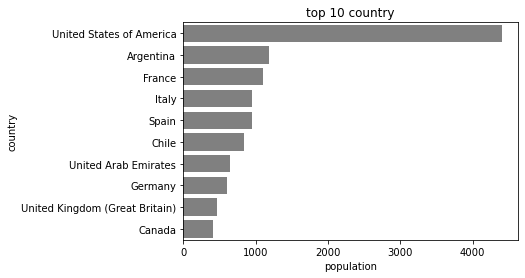

In [100]:
top_10_country = users.country.value_counts().head(10).reset_index()
top_10_country.rename(columns={top_10_country.columns[0]:"country",top_10_country.columns[1]:"population"},inplace=True)

plt.title('top 10 country')
sns.barplot(data=top_10_country,x='population',y='country',color='gray')

# Рассмотрим, различается ли количество пользователей с опытом премиум статуса? (was_premium)

In [101]:
was_premium = pd.crosstab(users.was_premium,users.group)
was_premium

group,control_1,control_2,test
was_premium,,,
False,3904,3853,3900
True,436,411,408


In [102]:
scipy.stats.chi2_contingency(was_premium[['control_1','control_2']])

Chi2ContingencyResult(statistic=0.3573478117515966, pvalue=0.5499828952030068, dof=1, expected_freq=array([[3912.75918178, 3844.24081822],
       [ 427.24081822,  419.75918178]]))

In [103]:
was_premium['control'] = was_premium['control_1']+was_premium['control_2']


In [104]:
scipy.stats.chi2_contingency(was_premium[['control','test']]).pvalue

0.5195350177767093

In [105]:
scipy.stats.chi2_contingency(was_premium[['control_1','control_2','test']]).pvalue
#Здесь я хотел посмотреть на разницу p-value и увидеть то, на сколько более чувствительным становится тест при объединении контролей

0.649565088794283

Статистически значимого различия не обнаружено

# Рассмотрим, различаются ли половые группы 

In [106]:
gender = pd.crosstab(users.gender,users.group)
gender

group,control_1,control_2,test
gender,,,
0,182,195,202
1,4158,4069,4106


In [107]:
scipy.stats.chi2_contingency(gender[['control_1','control_2']]).pvalue

0.41940247806709796

In [108]:
gender['control'] = gender['control_1'] + gender['control_2']

In [109]:
scipy.stats.chi2_contingency(gender[['test','control']]).pvalue

0.4530220827691783

Статистически значимого различия по половому признаку не обнаружено 

# Различаются ли возрастные распределения? 

In [110]:
users.groupby('group').age.describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control_1,4340.0,32.095392,10.257466,16.0,24.0,30.0,38.0,99.0
control_2,4264.0,32.046201,10.170721,16.0,25.0,30.0,38.0,99.0
test,4308.0,31.889276,10.245287,16.0,25.0,30.0,38.0,99.0


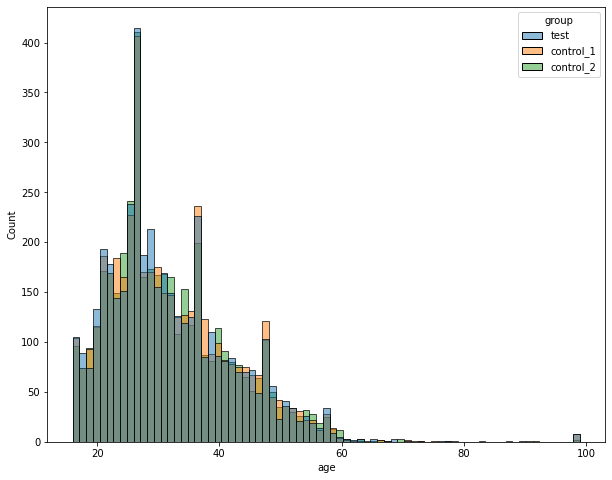

In [111]:
plt.figure(figsize=(10,8))
sns.histplot(data=users,x = users.age,hue='group')

In [112]:
scipy.stats.mannwhitneyu(users.query('group == "control_1"').age, users.query('group == "control_2"').age)

MannwhitneyuResult(statistic=9283252.5, pvalue=0.7919291369256963)

In [113]:
scipy.stats.mannwhitneyu(users.query('group_combined == "control"').age, users.query('group_combined== "test"').age)

MannwhitneyuResult(statistic=18736386.5, pvalue=0.3082535639645574)

Стат значимого различия в возрастах внутри групп также не обнаружено (это в целом мы могли понять и без статистических методов)

# Различаются ли коэф. привлекательности? 

In [114]:
users.groupby('group').attraction_coeff.describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control_1,4340.0,312.048848,320.972130,0.0,0.0,238.5,518.00,1000.0
control_2,4264.0,317.957317,326.191737,0.0,0.0,250.0,548.50,1000.0
test,4308.0,316.411328,323.373725,0.0,0.0,250.0,520.25,1000.0


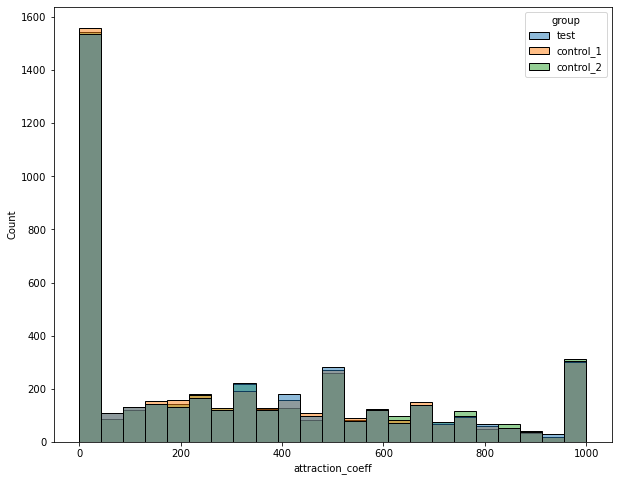

In [115]:
plt.figure(figsize=(10,8))
sns.histplot(data=users,x = users.attraction_coeff,hue='group')

In [116]:
scipy.stats.mannwhitneyu(users.query('group == "control_1"').attraction_coeff, users.query('group == "control_2"').attraction_coeff)

MannwhitneyuResult(statistic=9207595.0, pvalue=0.6876012572220559)

In [117]:
scipy.stats.mannwhitneyu(users.query('group_combined == "control"').attraction_coeff, users.query('group_combined== "test"').attraction_coeff)

MannwhitneyuResult(statistic=18470396.5, pvalue=0.7484879515627407)

Мы не видим значимого различия в распределениях, но я подумал о том, что возможно большинство нулевых значений не позволяют увидеть статистической разницы 

In [118]:
scipy.stats.kruskal(
    users.query('group_combined == "control" and attraction_coeff > 0').attraction_coeff, 
    users.query('group_combined== "test" and attraction_coeff > 0').attraction_coeff)

KruskalResult(statistic=0.02792255228862444, pvalue=0.8672910310182284)

Коэффиценты привлекательности также не различается 

# Поработаем с днями посещения 

In [119]:
users.visit_days = users.visit_days.fillna('') # заполняем пустные значения 

Функция для перевода дней из строки в список 

In [120]:
def get_visit_days(x): 
    if x == '': 
        return [0]
    else:
        return [0] + [int(day) for day in x.split(',')]

In [121]:
users['days_list'] = users.visit_days.apply(get_visit_days) # Список дней 

In [122]:
users['days_count'] = users.days_list.apply(lambda x: len(x)) # Количество дней посещения 

Посмотрим различаются ли количества дней посещения среди групп 

In [123]:
users.days_list.describe()

count     12912
unique     2133
top         [0]
freq       4018
Name: days_list, dtype: object

In [124]:
users.days_count.describe()

count    12912.00000
mean         5.55855
std          6.22509
min          1.00000
25%          1.00000
50%          3.00000
75%          8.00000
max         32.00000
Name: days_count, dtype: float64

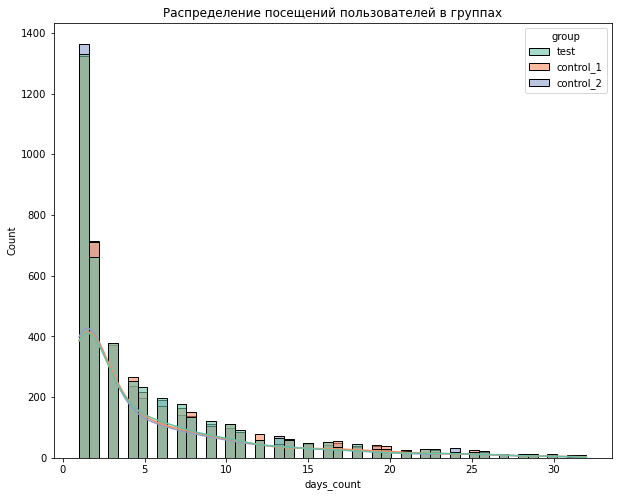

In [125]:
plt.figure(figsize=(10,8))
plt.title('Распределение посещений пользователей в группах')
sns.histplot(data=users,x=users.days_count,kde=True,hue='group',alpha=0.6, palette='Set2')

In [126]:
scipy.stats.mannwhitneyu(
    users.query('group == "control_1"').days_count,
    users.query('group == "control_2"').days_count)

MannwhitneyuResult(statistic=9448306.0, pvalue=0.0839835081866715)

In [127]:
scipy.stats.mannwhitneyu(
    users.query('group_combined == "control"').days_count,
    users.query('group_combined == "test"').days_count)

MannwhitneyuResult(statistic=18342459.0, pvalue=0.3312641031246273)

Стат. значимой разницы не обнаружено 

Учтём только "активных пользователей"  - тоесть тех, кто возвращался в платформу после нулевого дня

In [128]:
scipy.stats.mannwhitneyu(
    users.query('group == "control_1" and days_count != 0').days_count,
    users.query('group == "control_2"and days_count != 0').days_count)

MannwhitneyuResult(statistic=9448306.0, pvalue=0.0839835081866715)

In [129]:
scipy.stats.mannwhitneyu(
    users.query('group_combined == "control"and days_count != 0 and days_count != 0').days_count,
    users.query('group_combined == "test"and days_count != 0').days_count)

MannwhitneyuResult(statistic=18342459.0, pvalue=0.3312641031246273)

Посмотрим на распределение посещений пользователей с купленным премиальным статусом 

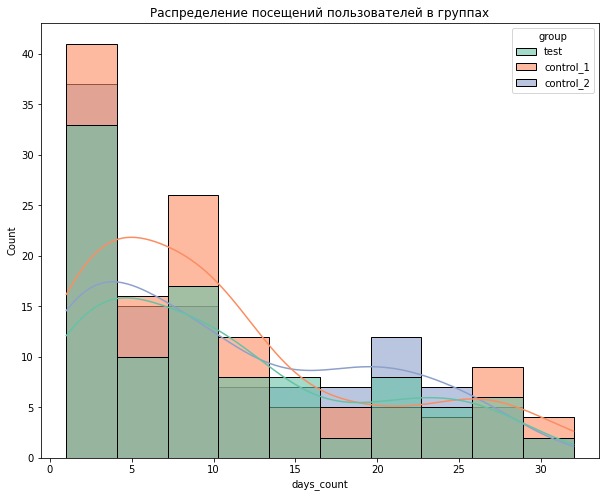

In [130]:
plt.figure(figsize=(10,8))
plt.title('Распределение посещений пользователей в группах')
sns.histplot(data=users.query('is_premium == True'),x=users.days_count,kde=True,hue='group',alpha=0.6, palette='Set2')

In [131]:
scipy.stats.mannwhitneyu(
    users.query('group == "control_1" and is_premium == True').days_count,
    users.query('group == "control_2"and is_premium == True').days_count)

MannwhitneyuResult(statistic=7105.5, pvalue=0.8052210728441742)

In [132]:
scipy.stats.mannwhitneyu(
    users.query('group_combined == "control" and is_premium == True').days_count,
    users.query('group_combined == "test" and is_premium == True').days_count)

MannwhitneyuResult(statistic=11718.0, pvalue=0.7973938437669149)

# Retention

Посмотрим различается ли retention в наших группах

In [133]:
retention_groups = users.groupby('group').days_list.apply(lambda x: x.explode()).reset_index() \
.groupby('group',as_index=False).days_list.value_counts()


In [134]:
retention_groups.sort_values('days_list')

,group,days_list,count
0,control_1,0,4340
36,control_2,0,4264
72,test,0,4308
1,control_1,1,2635
37,control_2,1,2521
...,...,...,...
69,control_2,150,2
34,control_1,150,1
68,control_2,180,2
107,test,180,1


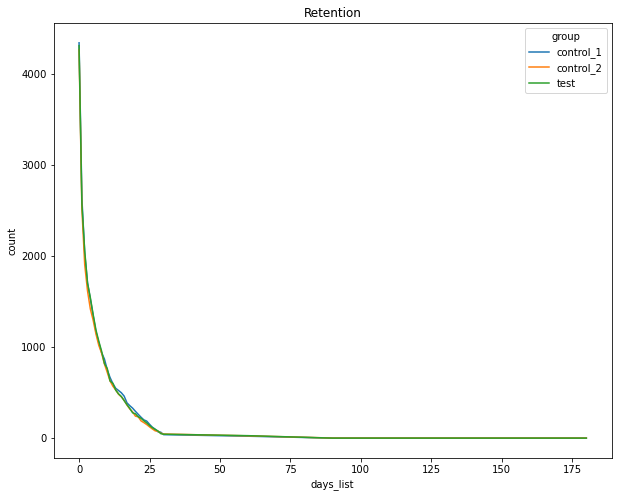

In [135]:
plt.figure(figsize=(10,8))
plt.title('Retention')
sns.lineplot(data=retention_groups,x='days_list',y='count',hue='group')

Ощутимой разницы в retention между гурппами мы не наблюдаем
Сам retention со временем выходит на "плато" и не опускается до нуля (что есть хорошо, но конечно не идельно) 

# Доля людей с премиум статусом без вовзвращения в сервис 

In [136]:
users.query('is_premium == True').groupby('group',as_index=False).days_count.value_counts(normalize=True).query('days_count==1') 

,group,days_count,proportion
1,control_1,1,0.094488
28,control_2,1,0.131579
57,test,1,0.111111


In [137]:
users.query('days_count==1 and is_premium == True').shape[0] / users.query('is_premium == True').shape[0] 

0.11176470588235295

Тот факт, что 10-15% пользователей с купленным премиумом в каждой группе не возвращались в продукт после регистрации требует дополнительной проверки


In [138]:
premium_no_days = users.query('is_premium==True and days_count==1').uid # Берём тех, кто со статусом премиума но не возвращался


In [139]:
transactions[transactions['uid'].isin(premium_no_days)]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group,group_combined
40,892093275.0,United States of America,2017-10-21 09:18:00,2017-10-28 11:18:00,12727.0,147.0,trial_vip_popup,trial_premium,test,test
97,891231273.0,United States of America,2017-07-11 03:39:00,2017-11-14 09:47:00,12727.0,147.0,trial_vip_popup,trial_premium,test,test
101,892084260.0,Canada,2017-10-21 13:30:00,2017-10-28 15:32:00,9815.0,147.0,trial_vip_popup,trial_premium,test,test
108,892050060.0,United States of America,2017-10-22 03:05:00,2017-10-29 05:05:00,9087.0,147.0,trial_vip_popup,trial_premium,test,test
121,892431081.0,United States of America,2017-10-14 06:58:00,2017-10-23 12:40:00,9087.0,147.0,trial_vip_popup,trial_premium,test,test
133,891564672.0,Spain,2017-10-31 23:40:00,2017-10-31 23:44:00,6292.0,147.0,autoreply_message,premium_no_trial,test,test
150,892354869.0,United States of America,2017-10-15 18:50:00,2017-10-15 18:52:00,7956.0,147.0,autoreply_message,premium_no_trial,test,test
161,892131894.0,United States of America,2017-10-20 12:59:00,2017-10-28 15:00:00,12727.0,147.0,trial_vip_popup,trial_premium,test,test
168,892211106.0,France,2017-10-18 17:09:00,2017-10-18 17:31:00,4537.0,147.0,left_sidebar_menu,premium_no_trial,test,test
219,892408266.0,France,2017-10-14 18:47:00,2017-10-23 13:05:00,16653.0,147.0,autoreply_message,trial_premium,test,test


In [140]:
print('Количество пользователей с прмиумом и без возвращения в продукт:',premium_no_days.nunique())
print('Количество уникальных пользователей без возвращения в продукт по транзакциям:',transactions[transactions['uid'].isin(premium_no_days)].uid.nunique())

Количество пользователей с прмиумом и без возвращения в продукт: 38
Количество уникальных пользователей без возвращения в продукт по транзакциям: 38


Количество пользователей по транзакциям и по users совпадает

Но есть ключевой вопрос, пользователи не возвращались в продукт, но оформляли его со страниц приложения на много позже даты регистрации 

Данная ситуация точно требует уточнения 

# Выручка

In [141]:
users.total_revenue.describe()

count     12912.000000
mean        429.294997
std        4767.496332
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      403104.000000
Name: total_revenue, dtype: float64

In [142]:
scipy.stats.mannwhitneyu(users.query('group=="control_1"').total_revenue,users.query('group=="control_2"').total_revenue)

MannwhitneyuResult(statistic=9280031.0, pvalue=0.4741767583752947)

Контрольные группы не различаются

# Рассмотрим различаются ли распределения total_revenue 

In [143]:
users.query('group=="test"').total_revenue.describe()

count      4308.000000
mean        445.974234
std        4075.186425
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      129870.000000
Name: total_revenue, dtype: float64

In [144]:
users.query('group!="test"').total_revenue.describe()

count      8604.000000
mean        420.943747
std        5079.006441
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      403104.000000
Name: total_revenue, dtype: float64

In [145]:
scipy.stats.mannwhitneyu(users.query('group=="test"').total_revenue,users.query('group!="test"').total_revenue)

MannwhitneyuResult(statistic=18393234.0, pvalue=0.027773561202297823)

Видим статистическую разницу в распределениях 

In [146]:
scipy.stats.mannwhitneyu(users.query('group=="test"').total_revenue,users.query('group!="test"').total_revenue,alternative='less')

MannwhitneyuResult(statistic=18393234.0, pvalue=0.013886780601148912)

Тест Манна-Уитни говорит нам, что распределение теста смещено в меньшую сторону по сравнению с контролем

Text(0, 0.5, 'Частота')

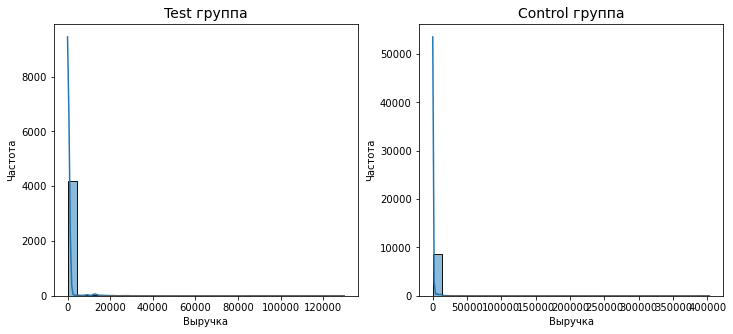

In [147]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(users.query('group=="test"')['total_revenue'], ax=ax1, kde=True, bins=30)
ax1.set_title('Test группа', fontsize=14)
ax1.set_xlabel('Выручка')
ax1.set_ylabel('Частота')


sns.histplot(users.query('group!="test"')['total_revenue'], ax=ax2, kde=True, bins=30)
ax2.set_title('Control группа', fontsize=14)
ax2.set_xlabel('Выручка')
ax2.set_ylabel('Частота')

Возможно график не даёт возможности подробно увидить распределение, но главное что мы видим - у test значений в 0 больше чем у объединённых контрольных групп!

In [148]:
scipy.stats.kruskal(
    users.query('group == "test"').total_revenue,
    users.query('group == "control_1"').total_revenue,
    users.query('group == "control_2"').total_revenue)

KruskalResult(statistic=5.3829696393090245, pvalue=0.06778022320998775)

Итак,интересный момент, тест краскала уоллеса статистиеских различий на этой выборке не обнаружил, но у нас получилось выявить статистически значимое различие total_revenue между объеденённым контролем и тестом. 

Выручка с клиента у теста смещена в меньшую сторону чем у контроля 



# Но что если мы хотим узнать изменение именно ARPU (выручки на пользователя)

В этом случае я предлагаю использовать бутстрап

Встроенный в scipy.stats бутстрап приводит к зависанию jupyter, поэтому сделаем его сами

In [149]:
test_total_revenue = users[users['group_combined']=='test']['total_revenue']
control_total_revenue = users[users['group_combined']=='control']['total_revenue']


In [ ]:
def boot_bca(x, y, stat, conf_level=0.95, reps=10000, seed=2112):

    boot_data = []
    np.random.seed(seed=seed)
    sample_stat = stat(x) - stat(y) #выборочное различие

    for _ in range(reps):
    #обычный бутстрап
        sample_x = x.sample(frac=1, replace=True)
        sample_y = y.sample(frac=1, replace=True)
        sample_stat_diff = stat(sample_x) - stat(sample_y)
        boot_data.append(sample_stat_diff)

    boot_data = np.array(boot_data)
    
    #оцениваем смещение с помощью функции нормального распределения
    #здесь знак смещения будет противоположен формуле из прошлой части
    z0 = scipy.stats.norm.ppf(np.mean(boot_data < sample_stat))
    
    #оцениваем "ускорение" с помощью метода jackknife
    part_1 = []
    part_2 = []
    
    for i in range(len(x)):
        part_1.append(stat(np.delete(x.to_numpy(), i)) - stat(y.to_numpy())) #Jacknife для x
    for i in range(len(y)):
        part_2.append(stat(x.to_numpy()) - stat(np.delete(y.to_numpy(), i))) #jacknife для y
        
    jack_samples = np.concatenate([part_1, part_2])
    uu = np.mean(jack_samples) - jack_samples # вычисляем отклонения 
    acc = np.sum(uu*uu*uu)/(6*(np.sum(uu*uu))**1.5)
    
    #считаем итоговый интервал
    alpha = 1 - conf_level
    zalpha = scipy.stats.norm.ppf([alpha/2, 1 - (alpha/2)])
    new_quants = scipy.stats.norm.cdf(z0 + (z0+zalpha)/(1-acc*(z0+zalpha)))
    conf_lo, conf_hi = np.quantile(boot_data, new_quants)
    
    return(f"95% CI: [{conf_lo:.2f}, {conf_hi:.2f}]")

In [ ]:
boot_bca(test_total_revenue,control_total_revenue,np.mean)

Доверительные интервалы включают в себя 0, а значит статистической значимой разницы не обнаружено 

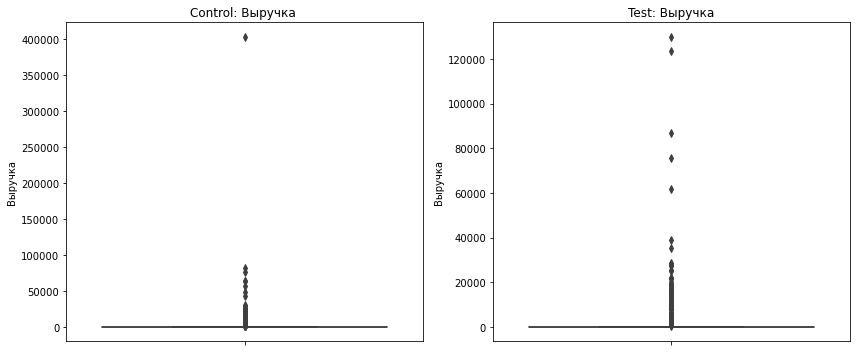

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot для control
sns.boxplot(y=control_total_revenue, ax=axes[0])
axes[0].set_title('Control: Выручка ')
axes[0].set_ylabel('Выручка')

# Boxplot для test
sns.boxplot(y=test_total_revenue, ax=axes[1])
axes[1].set_title('Test: Выручка')
axes[1].set_ylabel('Выручка')

plt.tight_layout()
plt.show()

In [153]:
control_total_revenue.describe()

count      8604.000000
mean        420.943747
std        5079.006441
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      403104.000000
Name: total_revenue, dtype: float64

In [154]:
test_total_revenue.describe()

count      4308.000000
mean        445.974234
std        4075.186425
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      129870.000000
Name: total_revenue, dtype: float64

Возможно выбросы не дают нам увидеть статистической разницы! (с этим мы столкнёмся и далее) 

In [155]:
q=0.98
control_total_revenue_trimmed =  control_total_revenue[control_total_revenue <= control_total_revenue.quantile(q)]
test_total_revenue_trimmed = test_total_revenue[test_total_revenue <= test_total_revenue.quantile(q)]

In [156]:
control_total_revenue.quantile(q)

7380.8800000000265

In [157]:
test_total_revenue.quantile(q)

9087.0

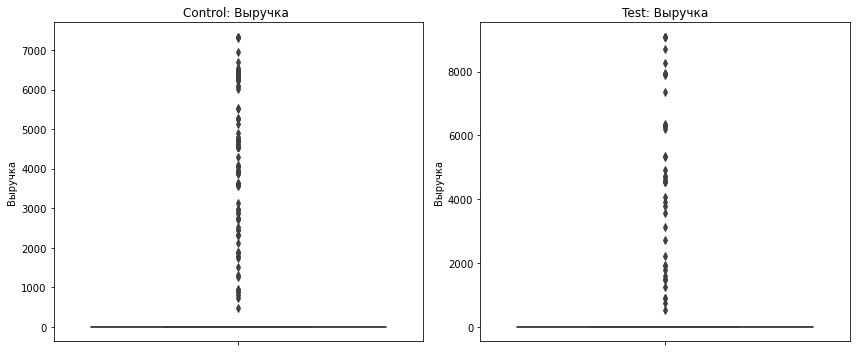

In [158]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot для control
sns.boxplot(y=control_total_revenue_trimmed, ax=axes[0])
axes[0].set_title('Control: Выручка ')
axes[0].set_ylabel('Выручка')

# Boxplot для test
sns.boxplot(y=test_total_revenue_trimmed, ax=axes[1])
axes[1].set_title('Test: Выручка')
axes[1].set_ylabel('Выручка')

plt.tight_layout()
plt.show()

In [159]:
boot_bca(test_total_revenue_trimmed,control_total_revenue_trimmed,np.mean)

'95% CI: [-58.04, -14.85]'

In [160]:
test_total_revenue_trimmed.describe()

count    4222.000000
mean       46.679299
std       536.965965
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      9087.000000
Name: total_revenue, dtype: float64

In [161]:
control_total_revenue_trimmed.describe()

count    8431.000000
mean       84.300320
std       667.579071
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      7332.000000
Name: total_revenue, dtype: float64

In [162]:
control_big =  control_total_revenue[control_total_revenue >= control_total_revenue.quantile(q)]
test_big = test_total_revenue[test_total_revenue >= test_total_revenue.quantile(q)]

In [163]:
boot_bca(test_big,control_big,np.mean)

'95% CI: [-4598.05, 8222.85]'

С небольшой обработкой данных мы можем выявить статистически значимый упадок в выручке на клиента 


Но я хочу обратить внимание, что для статистически значимого результата мы отсекли достаточно обеспеченных клиентов, влияниие которых может сыграть большую роль не только в статистическом тесте, но и на выручке компании в целом



# Различается ли доля платящих пользователей в группах?

In [164]:
paying_users = users.query('total_revenue > 0').groupby('group',as_index=False).uid.nunique()
no_paying_users =  users.query('total_revenue <= 0').groupby('group',as_index=False).uid.nunique()
contingency_paying = pd.merge(paying_users,no_paying_users,on='group').rename(columns={'uid_x':'paying','uid_y':'non_payin'}).T

contingency_paying.columns  = contingency_paying.iloc[0]
contingency_paying = contingency_paying[1:]
scipy.stats.chi2_contingency(contingency_paying).pvalue

0.057042658225599355

In [165]:
scipy.stats.chi2_contingency(contingency_paying[['control_1', 'control_2']]).pvalue

0.5272329598666372

In [166]:
contingency_paying['control']= contingency_paying['control_1']+contingency_paying['control_2']
scipy.stats.chi2_contingency(contingency_paying[['test','control']]).pvalue

0.025501811341746377

In [167]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
users['is_paying'] = (users['total_revenue'] > 0).astype(int)

model = smf.logit('is_paying ~ C(group_combined)', data=users).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.151271
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              is_paying   No. Observations:                12912
Model:                          Logit   Df Residuals:                    12910
Method:                           MLE   Df Model:                            1
Date:                Tue, 17 Feb 2026   Pseudo R-squ.:                0.001370
Time:                        23:16:47   Log-Likelihood:                -1953.2
converged:                       True   LL-Null:                       -1955.9
Covariance Type:            nonrobust   LLR p-value:                   0.02061
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -3.2441      0.057    -57.198      0.000      -3.

Мы видим различие между долей платящих пользователей в тесте и контроле 

Хочу обратить внимание, что доля платящих и конверсия в премиум разные величины
Оформления премиума могло быть и без транзакций оплаты 

Мы видим что факт нахождения в тестовой группе статистически значимо уменьшает шансы на статус платящего пользователя 

Я предпологаю что различие в платящих пользователях обусловленно разным количеством моенток (с помощью которых можно делать покупки)

In [168]:
users.query('group_combined == "test"').coins.describe()

count    4308.000000
mean        2.614206
std       129.608910
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      8466.000000
Name: coins, dtype: float64

In [169]:
users.query('group_combined == "control"').coins.describe()

count     8604.000000
mean        12.303696
std       1078.326321
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99958.000000
Name: coins, dtype: float64

In [170]:
users.query('group_combined == "test" and coins != 0').coins.describe()

count      49.000000
mean      229.836735
std      1205.819471
min         1.000000
25%         4.000000
50%         9.000000
75%        72.000000
max      8466.000000
Name: coins, dtype: float64

In [171]:
users.query('group_combined == "control" and coins != 0').coins.describe()

count      121.000000
mean       874.884298
std       9088.522317
min          1.000000
25%          6.000000
50%         10.000000
75%         28.000000
max      99958.000000
Name: coins, dtype: float64

In [172]:
scipy.stats.mannwhitneyu(users.query('group_combined == "test"').coins, users.query('group_combined == "control"').coins,alternative='greater')

MannwhitneyuResult(statistic=18483213.5, pvalue=0.8967148957230987)

Моя гипотеза не подтвердилась

# Возможно различаются виды транзакций?
Я предпологаю, что в тесте пользователи чаще покупали подписки за койны, что уменьшило выручку


In [173]:
scipy.stats.chi2_contingency(pd.crosstab(transactions.query('group != "test"').group, transactions.product_type)).pvalue

0.37261465635519364

В контрольных группах виды транзакций не различаются

In [174]:
scipy.stats.chi2_contingency(pd.crosstab(transactions.group_combined, transactions.product_type)).pvalue

0.13642586790371833

Между тестом и контролем также нет различий 

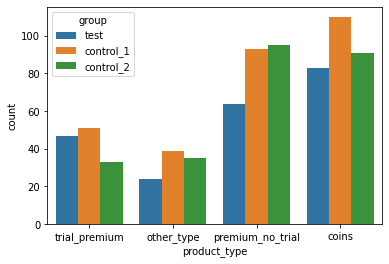

In [175]:
sns.countplot(data=transactions, x= transactions.product_type,hue='group')

И эта гипотеза, к сожелению, не подтвердилась

# Разберём выручку с платящего клиента

Text(0, 0.5, 'Частота')

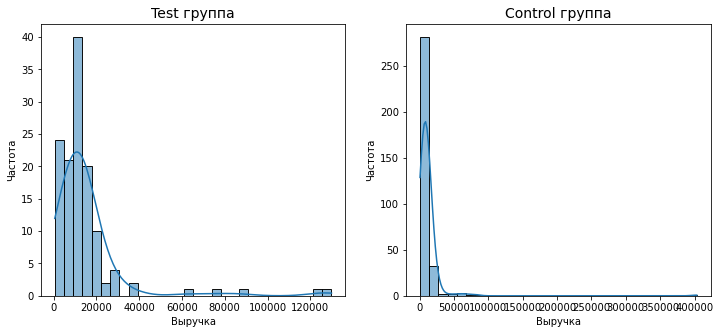

In [176]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(users.query('group=="test"and total_revenue != 0')['total_revenue'], ax=ax1, kde=True, bins=30)
ax1.set_title('Test группа', fontsize=14)
ax1.set_xlabel('Выручка')
ax1.set_ylabel('Частота')


sns.histplot(users.query('group!="test" and total_revenue != 0')['total_revenue'], ax=ax2, kde=True, bins=30)
ax2.set_title('Control группа', fontsize=14)
ax2.set_xlabel('Выручка')
ax2.set_ylabel('Частота')

In [177]:
control_1_total_payed = users.query('group=="control_1" and total_revenue != 0').total_revenue
control_2_total_payed = users.query('group=="control_2" and total_revenue != 0').total_revenue

control_total_payed =  users.query('group_combined=="control" and total_revenue != 0').total_revenue
test_total_payed = users.query('group_combined=="test" and total_revenue != 0').total_revenue


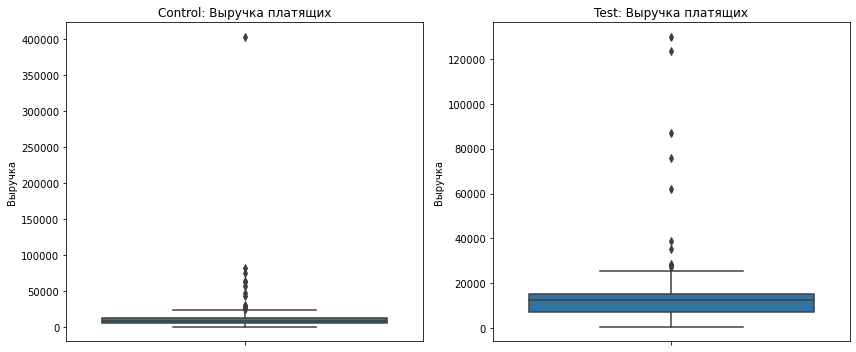

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot для control
sns.boxplot(y=control_total_payed, ax=axes[0])
axes[0].set_title('Control: Выручка платящих')
axes[0].set_ylabel('Выручка')

# Boxplot для test
sns.boxplot(y=test_total_payed, ax=axes[1])
axes[1].set_title('Test: Выручка платящих')
axes[1].set_ylabel('Выручка')

plt.tight_layout()
plt.show()

In [179]:
scipy.stats.mannwhitneyu(
    control_1_total_payed,
    control_2_total_payed)
    

MannwhitneyuResult(statistic=14036.0, pvalue=0.22220248280594002)

Распределения выручек у контрольных групп не различаются 

In [180]:
boot_bca(control_1_total_payed,control_2_total_payed,np.mean)

'95% CI: [87.10, 12617.52]'

ARPPU контрольных групп ЗНАЧИМО различаются!!!!!

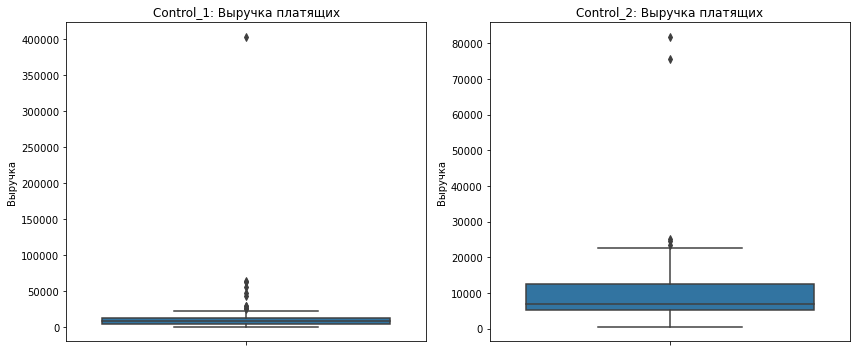

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot для control
sns.boxplot(y=control_1_total_payed, ax=axes[0])
axes[0].set_title('Control_1: Выручка платящих')
axes[0].set_ylabel('Выручка')

# Boxplot для test
sns.boxplot(y=control_2_total_payed, ax=axes[1])
axes[1].set_title('Control_2: Выручка платящих')
axes[1].set_ylabel('Выручка')

plt.tight_layout()
plt.show()

In [182]:
control_1_total_payed.describe()

count       169.000000
mean      12742.461538
std       31662.206253
min         806.000000
25%        5135.000000
50%        9087.000000
75%       12727.000000
max      403104.000000
Name: total_revenue, dtype: float64

In [183]:
control_2_total_payed.describe()

count      154.000000
mean      9534.571429
std       9424.818386
min        481.000000
25%       5265.000000
50%       6825.000000
75%      12418.250000
max      81796.000000
Name: total_revenue, dtype: float64

Я предполагаю, что выброс в первой контрольной группе привел к статистически значимой разнице ARPU

In [184]:
boot_bca(control_1_total_payed[control_1_total_payed < control_1_total_payed.max()],control_2_total_payed,np.mean)

'95% CI: [-1345.38, 2830.48]'

Да, при исключении выброса статистически значимой разницы не обнаружено

Я предлагаю просто объединить группы, опираясь на утверждение о равенстве контрольных групп

Приступим к сравнению теста и контроля:

In [185]:
scipy.stats.mannwhitneyu(control_total_payed,test_total_payed,alternative='less').pvalue.round(3)

0.0

А в этом случае мы видим статистически значимую разницу распределений (тоесть видим что значения в test смещены в большую сторону по срванению в control) 

Что на самом деле естественно, ведь мы повысили тарифы для этой группы

In [186]:
boot_bca(control_total_payed,test_total_payed,np.mean) # Не можем выявить значимую разницу ARPPU 

'95% CI: [-7872.32, 336.84]'

In [187]:
boot_bca(control_total_payed,test_total_payed,np.median) # Но медианы различаются (в целом об этом и говорил Манна-Уитни)

'95% CI: [-6162.00, -2691.00]'

In [188]:
control_total_payed.describe()

count       323.000000
mean      11213.003096
std       23829.032843
min         481.000000
25%        5200.000000
50%        7930.000000
75%       12603.500000
max      403104.000000
Name: total_revenue, dtype: float64

In [189]:
test_total_payed.describe()

count       128.000000
mean      15009.820312
std       18517.087173
min         533.000000
25%        7120.750000
50%       12597.000000
75%       15197.000000
max      129870.000000
Name: total_revenue, dtype: float64

Я предлагаю усечь часть значений и посмотреть 

In [190]:
q = 0.99

In [191]:
control_total_payed_trimmed = control_total_payed[control_total_payed <= control_total_payed.quantile(q)]
test_total_payed_trimmed = test_total_payed[test_total_payed <= test_total_payed.quantile(q)]

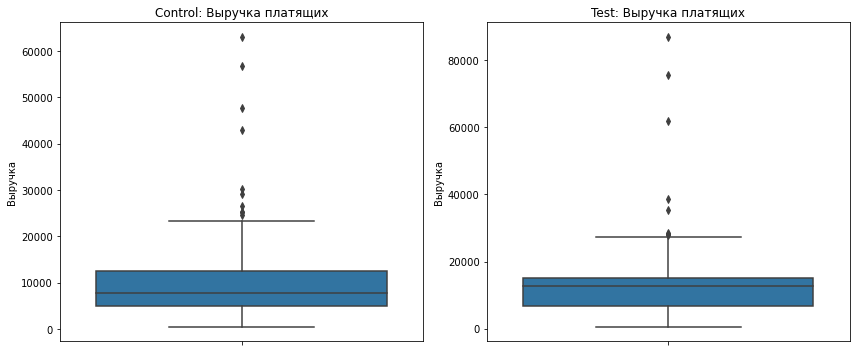

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot для control
sns.boxplot(y=control_total_payed_trimmed, ax=axes[0])
axes[0].set_title('Control: Выручка платящих')
axes[0].set_ylabel('Выручка')

# Boxplot для test
sns.boxplot(y=test_total_payed_trimmed, ax=axes[1])
axes[1].set_title('Test: Выручка платящих')
axes[1].set_ylabel('Выручка')

plt.tight_layout()
plt.show()

In [193]:
boot_bca(test_total_payed_trimmed,control_total_payed_trimmed,np.mean)

'95% CI: [1938.44, 6599.36]'

Теперь мы видим статистически значимую различие в тестовой и контрольной группе 

# Исследуем изменение платёжной системы

Итак, с небольшой наводкой мы узнали что payment_id это не айди платежа, а айди платёжной системы 
Рассмотрим какие платёжные системы у нас есть в целом

In [194]:
test_payment_id = transactions.query('group == "test"').payment_id.unique()
control_payment_id =  transactions.query('group_combined == "control"').payment_id.unique()


In [195]:
test_payment_id

array([147.,  67.,  19., 146.,  68.])

In [196]:
control_payment_id

array([147.,  19., 127.,  67.,  68., 146.,   0.])

Из условий задачи мы понимаем, что в рамках теста была изменена стоимость именно premium_no_trial по 2 новым. Узнаем какие именно платёжным системам. Найдём их!

In [197]:
test_payment_id_notrial = transactions.query('group == "test" and product_type == "premium_no_trial"').payment_id.unique()
control_payment_id_notrial =  transactions.query('group_combined == "control" and product_type == "premium_no_trial"') \
.payment_id.unique()



In [198]:
test_payment_id_notrial

array([147.,  68.])

In [199]:
control_payment_id_notrial

array([147.,  68.,   0.])

Интересно, в контроле было 3 платёжные системы из этой категории. 

Для сравнения будем использовать те платёжные системы, что были и в тесте 

In [200]:
transactions.query('group_combined == "control" and product_type == "premium_no_trial"').payment_id.value_counts()

147.0    158
68.0      28
0.0        2
Name: payment_id, dtype: int64

Пожертвуем мы всего двумя транзакциями, я думаю это несущественно повлияет на анализ 

In [201]:
transactions.query('payment_id == 0 and product_type == "premium_no_trial"')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group,group_combined
399,891216033.0,United States of America,2017-07-11 12:33:00,2017-07-11 12:47:00,6292.0,0.0,autoreply_message,premium_no_trial,control_1,control
698,891219540.0,Australia,2017-07-11 10:50:00,2017-07-11 10:58:00,4719.0,0.0,none,premium_no_trial,control_2,control


In [202]:
transactions.shape

(765, 10)

In [203]:
transactions = transactions.query('not (payment_id == 0 and product_type == "premium_no_trial")')

In [204]:
transactions.shape

(763, 10)

# Рассмотрим изменение метрик

Посмотрим как изменились транзакции на подписку  без пробного периода

In [205]:
transactions.query('product_type == "premium_no_trial"').groupby('group').revenue.describe()
#Стоимость подписки без пробного была увеличина 


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control_1,92.0,7590.728261,11251.125096,1508.0,4537.00,6292.0,6292.0,63037.0
control_2,94.0,7160.095745,9900.024713,1482.0,4572.75,6292.0,6292.0,81796.0
test,64.0,11212.703125,18786.406048,1898.0,6002.75,8021.0,11238.5,113477.0


In [206]:
transactions.query('product_type == "trial_premium"').groupby('group').revenue.describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control_1,51.0,11746.392157,2218.054887,9087.0,9639.5,12727.0,12909.0,17199.0
control_2,33.0,12272.393939,2835.876859,7033.0,9945.0,12727.0,12935.0,16952.0
test,47.0,12877.191489,2494.244572,7254.0,12662.0,12727.0,14137.5,16653.0


Даётся ли пробная подписка единоразово? Или статус подписки с пробным остаётся в дальнейшем? 

In [207]:
transactions.query('product_type == "trial_premium"').groupby('uid',as_index=False).revenue.count().query('revenue >1')

,uid,revenue
19,891297711.0,2


Мы видим что в большинстве случаев оформление премиум подписки единоразова, но у нас есть человек оформивший её дважды 

К сожалению я не знаю ошибка это или работа поддержки (например человек не смог пользоваться сервисом после оформления пробной подписки и служба поддержки пошла на встречу и позволила оформить подписку повторно) 


In [208]:
transactions.query('uid == 891297711.0')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group,group_combined
105,891297711.0,Spain,2017-06-11 01:35:00,2017-11-13 03:46:00,12818.0,147.0,trial_vip_popup,trial_premium,test,test
177,891297711.0,Spain,2017-06-11 01:35:00,2017-11-13 03:42:00,12818.0,147.0,autoreply_message,trial_premium,test,test


Моя гипотеза о работе с поддержкой сразу отпала :) 

Уберём этот конкретный случай 

In [209]:
transactions = transactions.drop(105)

In [210]:
transactions.query('group_combined == "test" and product_type == "premium_no_trial"').country.value_counts()

United States of America          19
Italy                              6
Spain                              5
United Kingdom (Great Britain)     5
United Arab Emirates               5
Chile                              5
Argentina                          5
Canada                             3
France                             3
Israel                             2
Germany                            2
Mexico                             1
Turkey                             1
Latvia                             1
Belgium                            1
Name: country, dtype: int64

In [211]:
transactions.query('group_combined == "test"').country.value_counts()

United States of America          77
France                            22
Spain                             20
Italy                             14
Israel                            14
United Kingdom (Great Britain)    11
Argentina                         10
United Arab Emirates               9
Chile                              9
Canada                             9
Germany                            8
Latvia                             4
Switzerland                        4
Belgium                            3
Turkey                             2
Mexico                             1
Name: country, dtype: int64

Из условия задания мы знаем, что стоимость премиум подписки без пробного изменили в "нескольких" странах 

К сожалению, я не знаю в каких именно странах была изменена цена. И как мне кажется у нас слишком мало данных для просмотра изменения конверсий и выручки в разрезе стран и групп для построения каких-либо выводов 

Поэтому я буду смотреть изменения глобально по всем странам в выборках 

Изменилась ли конверсия в оформление премиум подписки без пробного периода?

Изменились ли предпочтения пользователей в подписках? 

In [212]:
uids_premium_no_trial_control = transactions \
.query('group_combined == "control" and product_type == "premium_no_trial" and payment_id in (147,68)').uid.nunique()

In [213]:
uids_premium_no_trial_test = transactions \
.query('group_combined == "test" and product_type == "premium_no_trial"').uid.nunique()

In [214]:
uids_premium_no_trial = transactions.query('product_type == "premium_no_trial"')\
.groupby(['group_combined','group'],as_index=False).uid.nunique()
uids_premium_no_trial.rename(columns={'uid':'count_no_trial'},inplace=True)
uids_premium_no_trial # Пользователи с подпиской без пробного

,group_combined,group,count_no_trial
0,control,control_1,88
1,control,control_2,91
2,test,test,60


In [215]:
uids_premium_trial = transactions.query('product_type == "trial_premium"').groupby(['group_combined','group'],as_index=False).uid.nunique()
uids_premium_trial.rename(columns={'uid':'count_trial'},inplace=True)
uids_premium_trial #Пользователи с пробной подпиской 

,group_combined,group,count_trial
0,control,control_1,51
1,control,control_2,33
2,test,test,46


In [216]:
uids_all = transactions.groupby(['group_combined','group'],as_index=False).uid.nunique()
uids_all.rename(columns={'uid':'all'},inplace=True)
uids_all # всего пользователей

,group_combined,group,all
0,control,control_1,168
1,control,control_2,153
2,test,test,128


In [217]:
uids_without_no_trial = transactions.query('product_type != "premium_no_trial"').groupby(['group_combined','group'],as_index=False).uid.nunique()
uids_without_no_trial.rename(columns = {'uid':'without_no_trial'},inplace=True)
uids_without_no_trial #Пользователи без подписки без пробного (для таблицы сопряжённости)

,group_combined,group,without_no_trial
0,control,control_1,117
1,control,control_2,97
2,test,test,89


In [218]:
uids_premium = pd.merge(uids_premium_no_trial,uids_premium_trial, on=['group','group_combined'])
uids_premium['total_premium'] = uids_premium['count_no_trial'] + uids_premium['count_trial'] # Всего с премиумом

In [219]:
uids_premium

,group_combined,group,count_no_trial,count_trial,total_premium
0,control,control_1,88,51,139
1,control,control_2,91,33,124
2,test,test,60,46,106


In [220]:
uids_premium = pd.merge(uids_premium,uids_all,on=['group','group_combined'])
uids_premium = pd.merge(uids_premium,uids_without_no_trial,on=['group_combined','group'])

In [221]:
uids_premium

,group_combined,group,count_no_trial,count_trial,total_premium,all,without_no_trial
0,control,control_1,88,51,139,168,117
1,control,control_2,91,33,124,153,97
2,test,test,60,46,106,128,89


In [222]:
uids_premium['part_no_trial_premium'] = uids_premium['count_no_trial'] / uids_premium['total_premium'] 
#Доля с премиумом без пробного среди подписок

In [223]:
uids_premium['part_no_trial_all'] = uids_premium['count_no_trial'] / uids_premium['all'] 
#Доля с премиум без пробного от всех 

In [224]:
uids_premium

,group_combined,group,count_no_trial,count_trial,total_premium,all,without_no_trial,part_no_trial_premium,part_no_trial_all
0,control,control_1,88,51,139,168,117,0.633094,0.523810
1,control,control_2,91,33,124,153,97,0.733871,0.594771
2,test,test,60,46,106,128,89,0.566038,0.468750


Сравним конверсию в покупку премиум подписки без пробного

In [225]:
scipy.stats.chi2_contingency(uids_premium[['count_no_trial','all','group']]\
                             .query('group != "test"').set_index('group')).pvalue

0.5568789115842381

In [226]:
scipy.stats.chi2_contingency(uids_premium.groupby('group_combined')[['count_no_trial','all']].sum()).pvalue

0.3876316817671819

Значимой разницы конверсии в подписку без пробного мы не наблюдаем

In [227]:
scipy.stats.chi2_contingency(uids_premium[['count_no_trial','count_trial','group']]\
                             .query('group != "test"').set_index('group')).pvalue

0.10580293683496424

In [228]:
scipy.stats.chi2_contingency(uids_premium[['count_no_trial','count_trial','group']].set_index('group')).pvalue

0.026477523145317965

In [229]:
scipy.stats.chi2_contingency(uids_premium.groupby('group_combined')[['count_no_trial','count_trial']].sum()).pvalue

0.04949621303959548

В свою очередь при сравнении долей подписок с пробным и без пробного периуда и теста и контроля мы наблюдаем статистически значимую разницу 

Интуитивно понятно: доля премиум статуса без пробной подписки в тесте по отношению с пробной действительно уменьшилась!

Это означает что люди отдают предпочтение в пользу подписки с пробным статусом (что естественно при увеличении цены) 

# Изменилась ли выручка с пользователя от подписки без пробного статуса

In [230]:
revenue_no_trial = transactions.query('product_type == "premium_no_trial" ') \
.groupby(['group','uid'],as_index=False).revenue.sum()

revenue_no_trial

,group,uid,revenue
0,control_1,891092322.0,5278.0
1,control_1,891120969.0,6292.0
2,control_1,891130164.0,4537.0
3,control_1,891131061.0,6292.0
4,control_1,891142386.0,4680.0
...,...,...,...
234,test,892370097.0,11115.0
235,test,892390170.0,5369.0
236,test,892405179.0,9100.0
237,test,892426491.0,12597.0


In [237]:
revenue_no_trial.describe()

,uid,revenue
count,2.390000e+02,239.000000
mean,8.917986e+08,8740.623431
std,4.126067e+05,13533.496960
min,8.910681e+08,1482.000000
25%,8.913925e+08,4712.500000
50%,8.918570e+08,6292.000000
75%,8.921684e+08,6558.500000
max,8.924355e+08,113477.000000


In [231]:
groups = ['control_1','control_2','test']

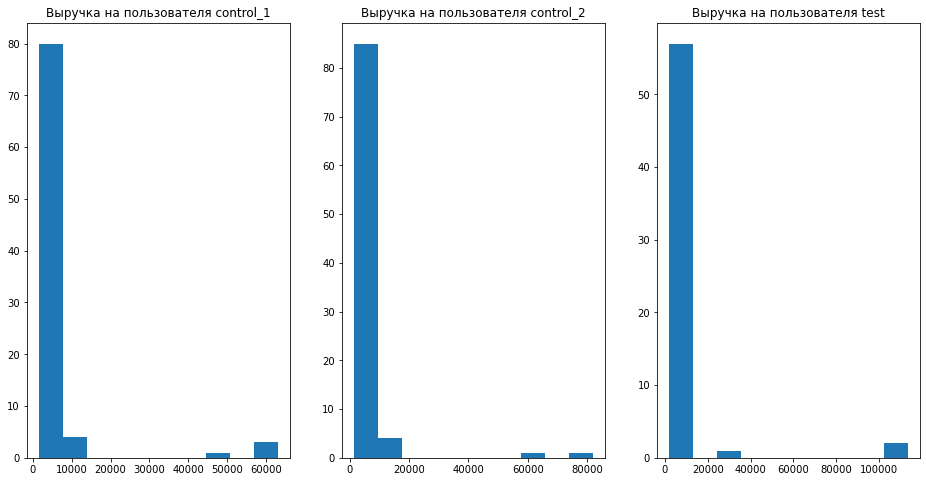

In [242]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize = (16,8))

for i, group in enumerate(groups):
    axes[i].hist(revenue_no_trial[revenue_no_trial['group']==group].revenue)
    axes[i].set_title(f'Выручка на пользователя {group}')

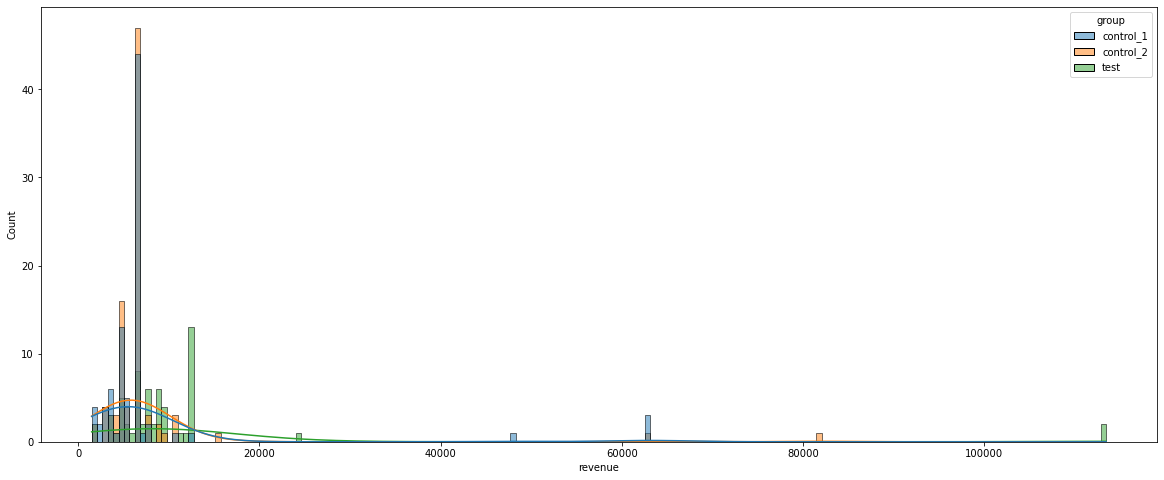

In [252]:
plt.figure(figsize=(20,8))
sns.histplot(data=revenue_no_trial, x='revenue',hue='group',kde=True)

In [260]:
for i, group in enumerate(groups):
    print(f'Основные показатели для {group}')
    print(revenue_no_trial[revenue_no_trial['group']==group].revenue.describe())
    print()

Основные показатели для control_1
count       88.000000
mean      7935.761364
std      11472.835247
min       1508.000000
25%       4537.000000
50%       6292.000000
75%       6292.000000
max      63037.000000
Name: revenue, dtype: float64

Основные показатели для control_2
count       91.000000
mean      7396.142857
std      10086.598233
min       1482.000000
25%       4686.500000
50%       6292.000000
75%       6318.000000
max      81796.000000
Name: revenue, dtype: float64

Основные показатели для test
count        60.000000
mean      11960.216667
std       19371.288200
min        1898.000000
25%        6288.750000
50%        8040.500000
75%       12597.000000
max      113477.000000
Name: revenue, dtype: float64



In [255]:
scipy.stats.mannwhitneyu(revenue_no_trial.query('group == "control_1"').revenue,
                         revenue_no_trial.query('group == "control_2"').revenue)

MannwhitneyuResult(statistic=3713.0, pvalue=0.3883832819726941)

Распределение контрольных групп статистически значимо не различается 

In [259]:
round(scipy.stats.mannwhitneyu(revenue_no_trial.query('group != "test"').revenue,
                         revenue_no_trial.query('group == "test"').revenue,alternative='less').pvalue,3)

0.0

А вот распредление выручки на платящего пользователя с премиум подписки  статистически значимо сдвинулось в большую сторону 

In [261]:
boot_bca(revenue_no_trial.query('group == "control_1"').revenue, revenue_no_trial.query('group == "control_2"').revenue, np.mean)

'95% CI: [-2623.05, 3803.11]'

In [262]:
boot_bca(revenue_no_trial.query('group != "test"').revenue, revenue_no_trial.query('group == "test"').revenue, np.mean)

'95% CI: [-12115.63, -691.58]'

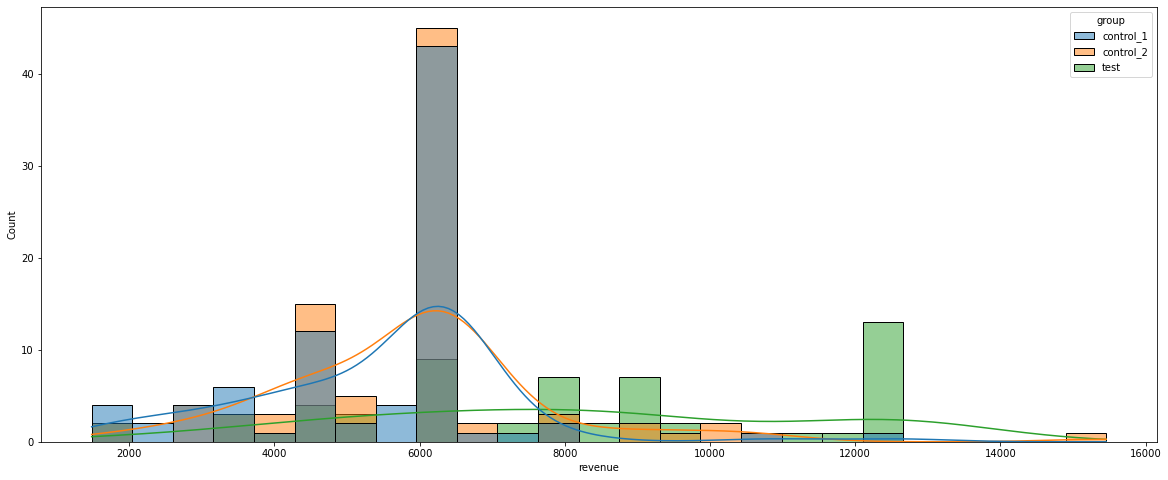

In [270]:
plt.figure(figsize=(20,8))
sns.histplot(data=revenue_no_trial[revenue_no_trial.revenue < 20000],
             x='revenue',hue='group',kde=True)

In [271]:
boot_bca(revenue_no_trial[revenue_no_trial.revenue < 20000].query('group != "test"').revenue, 
         revenue_no_trial[revenue_no_trial.revenue < 20000].query('group == "test"').revenue, np.mean)

'95% CI: [-3308.55, -1616.02]'

При рассмотре ARPPU на платящего пользователя premium_no_trial мы видим статистически значимое увлечение метрики как в общем на выборках, так и при рассмотре концентрированного большинства пользователей

# Резюмируем

Итак, какую картину мы наблюдаем:

1. Контрольные группы прошли тесты на соответствие друг с другом, что показывает правильность работы системы сплитования. Никакого смещения мы не наблюдали (не считая единичного выброса).

2. Также контроль не отличался от теста по групповым признакам (не считая наши измеримые метрики) 

3. Распределение платящих пользователей в тесте сместилось в большую сторону, и увеличилась средняя прибыль с платящего пользователя, что естественно при повышении тарифного плана. Об этом нам говорит и увеличение метрик выручки на пользователя при рассмотрении премиум подписок без пробного статуса.

4. Конверсия в оформление премиум статуса не отличалась у групп, также мы не получили статистически значимой разницы конверсии в оформление премиум подписки без пробного статуса. В то же время,  конверсия в оплату у пользователей снизилась, что отразилось на распределении выручки на пользователя и целевой метрики ARPU. 

Данные факты  наталкивает меня на мысль - да, увеличение стоимости привело к увеличении выручки на покупающего пользователя и казалось бы, конверсия статистичеси значимого уменьшения не показала, но прошу заострить своё внимание на том, что мы видим тенденцию к уменьшению пользовательской покупательной способности на платформе. Меньше пользователей готовы приносить деньги в продукт при высокой стоимости премиума. Мы видим, что больше пользователей выбирают пробную подписку и в дальнейшем заканчивают финансовые взаимоотношения с нашей платформой.

Выше мы получили C(group_combined)[T.test] = -0.2420
exp(-0.2420) ≈ 0.785, это означает, что шансы платить в тестовой группе ниже на 21.5%, а значит конверсия упала на 21.5%!
Это и становится причиной уменьшения выручки на пользователя. 

Также неизвестна реакция более обеспеченных пользователей платформы, что может негативно отразится на выручке компании. 
Для изменения тарифного плана и увеличении выручки требуется дополнительная стимуляция покупок в виде новых функций, возможностей, а может и появление новых видов премиум подписок с повышенным ценником.

Предлагаю отложить увеличение тарифного плана, либо продолжить тестирования для получения дополнительной информации.

